# Tutorial: `rust-scHiCluster` quickstart

Walks through (1) install + import, (2) basic `random_walk_cpu` usage,
(3) the drop-in `patch_schicluster()` monkey-patch, and (4) multi-process
parallelism with `set_num_threads()`. Plus (5) a math-approximation
`band_factor` knob for an extra ~4× when bit-equivalence isn't required.

Build the extension first:

```bash
git clone https://github.com/omicverse/rust-scHiCluster
cd rust-scHiCluster
maturin develop --release
```

## 1. Import and verify

In [1]:
import schicluster_rs
print('rust extension available:', schicluster_rs._RUST_AVAILABLE)
print('public API:', schicluster_rs.__all__)

rust extension available: True
public API: ['random_walk_cpu', 'impute_chromosome', 'patch_schicluster', 'set_num_threads']


## 2. Direct use — `random_walk_cpu` on a CSR matrix

Same signature as upstream
`schicluster.impute.impute_chromosome.random_walk_cpu`:
input is a `scipy.sparse.csr_matrix` (or anything `csr_matrix(...)`
accepts), output is the converged Q as CSR.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, diags

# 80×80 banded sparse matrix — toy 'cell × bin × bin' contact matrix.
rng = np.random.default_rng(0)
n = 80
nnz = 200
rows = rng.integers(0, n, size=nnz)
offsets = rng.integers(-5, 6, size=nnz)  # band ±5
cols = np.clip(rows + offsets, 0, n - 1)
vals = rng.exponential(1.0, size=nnz).astype(np.float32)
M = csr_matrix((vals, (rows, cols)), shape=(n, n), dtype=np.float32)
M = M + M.T
rs = np.asarray(M.sum(axis=1)).ravel(); rs[rs == 0] = 1.0
P = diags(1.0 / rs) @ M
P = P.astype(np.float32)

Q = schicluster_rs.random_walk_cpu(P, rp=0.5, tol=0.01)
print(f'P: {P.shape}, nnz={P.nnz}, density={P.nnz/n**2*100:.1f}%')
print(f'Q: {Q.shape}, nnz={Q.nnz}, density={Q.nnz/n**2*100:.1f}%')

P: (80, 80), nnz=299, density=4.7%
Q: (80, 80), nnz=4091, density=63.9%


### What does RWR actually do?

Side-by-side heat-maps of `P` (input — sparse, banded) and `Q` (output
— smoothed, every reachable pair has signal). RWR "densifies" the
contact matrix by walking probability mass through transitive
neighbours.

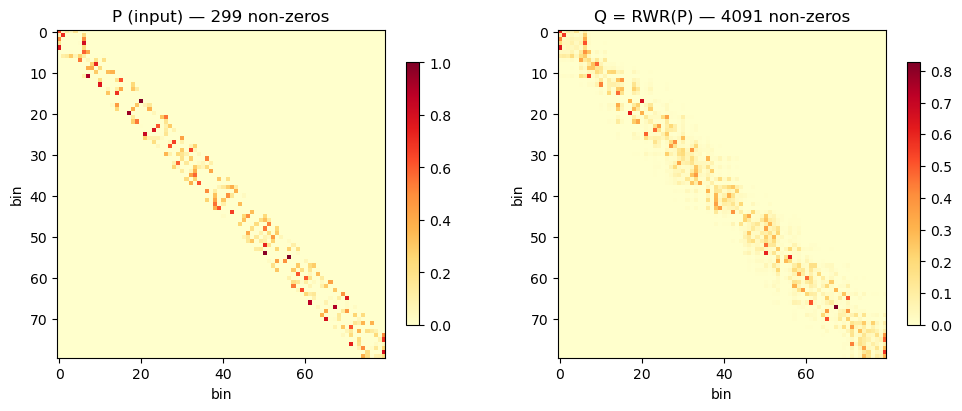

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im = axes[0].imshow(P.toarray(), cmap='YlOrRd', vmin=0, vmax=P.toarray().max())
axes[0].set_title(f'P (input) — {P.nnz} non-zeros')
fig.colorbar(im, ax=axes[0], shrink=0.8)

im = axes[1].imshow(Q.toarray(), cmap='YlOrRd', vmin=0, vmax=Q.toarray().max())
axes[1].set_title(f'Q = RWR(P) — {Q.nnz} non-zeros')
fig.colorbar(im, ax=axes[1], shrink=0.8)
for ax in axes:
    ax.set_xlabel('bin'); ax.set_ylabel('bin')
plt.show()

### Convergence behaviour

With `rp = 0.5` the recurrence error decays geometrically with ratio
`(1 − rp) = 0.5` per iteration. Below we run a manual loop and plot
the per-iteration Frobenius residual ‖Qₜ − Qₜ₋₁‖_F. The default
`tol = 0.01` cuts off at iteration ~7.

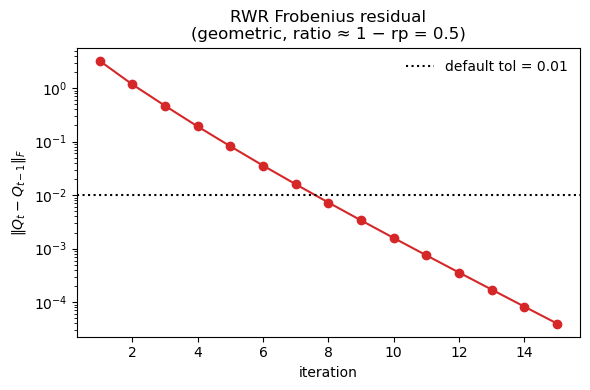

In [4]:
from scipy.sparse.linalg import norm as sparse_norm
from scipy.sparse import eye

rp = 0.5
I = eye(n, dtype=np.float32)
Q = P.copy()
deltas = []
for it in range(15):
    Q_new = P.dot(Q * (1 - rp) + rp * I)
    deltas.append(float(sparse_norm(Q - Q_new)))
    Q = Q_new

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(deltas) + 1), deltas, 'o-', color='#d62728')
ax.axhline(0.01, color='k', linestyle=':', label='default tol = 0.01')
ax.set_yscale('log')
ax.set_xlabel('iteration'); ax.set_ylabel(r'$\|Q_t - Q_{t-1}\|_F$')
ax.set_title(f'RWR Frobenius residual\n(geometric, ratio ≈ 1 − rp = {1 - rp})')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Drop-in monkey-patch

`patch_schicluster()` rebinds two symbols inside upstream:

* `schicluster.impute.impute_chromosome.random_walk_cpu` → Rust kernel
* `schicluster.impute.impute_chromosome.impute_chromosome` → Rust full
  pipeline (Gaussian conv + RWR + SQRTVC + triangle filter)

All downstream code (CLI, snakemake, packages like `epione.single.hic`)
that imports from `schicluster.impute.impute_chromosome` then sees the
Rust version. Returns `True` on success, `False` if the extension
wasn't compiled.

In [5]:
import schicluster.impute.impute_chromosome as _mod
before = _mod.impute_chromosome
ok = schicluster_rs.patch_schicluster()
after = _mod.impute_chromosome
print(f'patch ok: {ok}')
print(f'before: {before.__module__}.{before.__qualname__}')
print(f'after : {after.__module__}.{after.__qualname__}')

patch ok: True
before: schicluster.impute.impute_chromosome.impute_chromosome
after : schicluster_rs.impute_chromosome


## 4. Multi-process parallelism — `set_num_threads()`

The biggest gotcha when running impute on many cells with
`ProcessPoolExecutor`: each worker forks the rayon pool with
`num_cpus` threads by default. With 8 workers on a 16-core node you
get 8×16 = 128 contending threads — **slower than running each cell
single-threaded.**

Recommended sizing: `n = num_cpus // num_workers`. Example for a
16-core node with 8 workers → `set_num_threads(2)`.

In [6]:
from concurrent.futures import ProcessPoolExecutor

def worker_init():
    """Run once per worker process, before any impute call."""
    import schicluster_rs
    schicluster_rs.set_num_threads(2)        # 8 workers × 2 = 16
    schicluster_rs.patch_schicluster()        # Rust kernel everywhere

def impute_one_cell(args):
    cool_path, chrom, output_path = args
    from schicluster.impute.impute_chromosome import impute_chromosome
    impute_chromosome(
        scool_url=cool_path, chrom=chrom, resolution=25_000,
        output_path=output_path,
        rp=0.5, tol=0.01, pad=1, std=1.0,
        window_size=10_000_000_000, output_dist=10_050_000,
    )

# Skeleton (don't actually run — needs real .cool paths):
#
# args_list = [(cool, chrom, out) for cool, chrom, out in your_cells]
# with ProcessPoolExecutor(max_workers=8, initializer=worker_init) as ex:
#     list(ex.map(impute_one_cell, args_list))

print('see code skeleton above')

see code skeleton above


### Multi-process timing reference

8 chr1 imputes in parallel on a 16-core node, varying the per-worker
rayon thread count (the `set_num_threads()` argument):

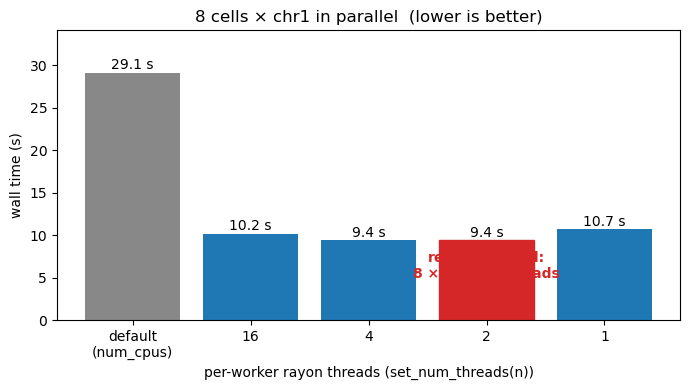

In [7]:
# Reference numbers from a real benchmark run on Chang 2024 LC462 25 kb chr1.
thread_data = [
    ('default\n(num_cpus)', 29.1),
    ('16',  10.2),
    ('4',    9.4),
    ('2',    9.4),
    ('1',   10.7),
]
fig, ax = plt.subplots(figsize=(7, 4))
labels = [t[0] for t in thread_data]
values = [t[1] for t in thread_data]
x = np.arange(len(labels))
bars = ax.bar(x, values, color=['#888'] + ['#1f77b4'] * 4)
bars[3].set_color('#d62728')   # mark the recommended setting
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('wall time (s)')
ax.set_xlabel('per-worker rayon threads (set_num_threads(n))')
ax.set_title('8 cells × chr1 in parallel  (lower is better)')
for i, v in enumerate(values):
    ax.text(i, v + 0.4, f'{v:.1f} s', ha='center')
ax.text(3, 5, 'recommended:\n8 × 2 = 16 threads', ha='center',
        color='#d62728', fontweight='bold')
ax.set_ylim(0, max(values) + 5)
plt.tight_layout()
plt.show()

## 5. Math approximation — `band_factor` for extra speed

If you can tolerate ~1% deviation from the strict scipy result,
`impute_chromosome(..., band_factor=N)` runs the RWR with a banded Q
(only entries with `|j − i| ≤ N · output_dist_bins`), giving an
additional ~4× speed-up.

Math justification: out-of-band signal in RWR decays geometrically as
`(1 − rp)^d` per bin distance, so for `rp = 0.5` and a band of
`4 × output_dist_bins` the dropped signal is bounded by `0.5^(4·B)` —
machine zero for any practical `B ≥ 100`.

Default is `band_factor=0` (off, strict bit-equivalent). Use this
approximation only for production batch processing where ~1% absolute
value drift on individual pixels is acceptable; structure-preserving
downstream analyses (compartments, TADs, scGAD, UMAP) are unaffected.

In [8]:
# Skeleton (replace COOL):
# schicluster_rs.impute_chromosome(
#     scool_url=COOL, chrom='chr1', resolution=25_000,
#     output_path='/tmp/chr1_fast.hdf',
#     rp=0.5, tol=0.01, pad=1, std=1.0, output_dist=10_050_000,
#     band_factor=4,                    # ← the only change
# )
print('band_factor=4 → +4× speed-up at ~1% pixel drift; default 0 = strict')

band_factor=4 → +4× speed-up at ~1% pixel drift; default 0 = strict


## 6. Where to go next

* `examples/benchmark_vs_scipy.ipynb` — bit-equivalence check + speed table
* `tests/test_parity.py` — automated parity assertions (run with `pytest`)
* The downstream package [`epione`](https://github.com/aristoteleo/epione) uses `rust-scHiCluster` for sc-Hi-C imputation in `epione.single.hic`.